In [ ]:
import sys
from importlib import reload
from pathlib import Path

REPO_ROOT = Path(r"C:\Projects\signia-fsl-recognition").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.training.trainer as trainer_module

trainer_module = reload(trainer_module)
TrainingConfig = trainer_module.TrainingConfig
train = trainer_module.train

from src.data_collection.dataset_builder import DatasetBuilder
from src.training.trainer import train, TrainingConfig

# 1. Preview what you've collected
builder = DatasetBuilder()
builder.print_summary()
# Label                          |   ID | Samples
# --------------------------------------------------
# GOOD MORNING                   |    0 |       5
# GOOD AFTERNOON                 |    1 |       3
# --------------------------------------------------

# 2. Merge collected samples into your existing .pt bundle
X, y = builder.merge_with_bundle("dynamic_dataset.npz")
# Loaded bundle: dynamic_dataset.npz
#   Base dataset: 1800 samples, shape (1800, 30, 126)
#   Merged 8 collected samples. Total: 1808 samples.

# 3. Save the merged bundle as a temp file and train from it
import torch
torch.save({"X": X, "y": y}, "data/merged_dataset.pt")

config = TrainingConfig(
    dataset_path="data/merged_dataset.pt",
    category="GREETING",
    labels_csv="csv/labels.csv",
    ...
)
results = train(config)




config = TrainingConfig(
    dataset_path=str(
        REPO_ROOT / "notebooks" / "02_dynamic" / "fsl_dataset_clean.pt"
    ),
    label_ids=[20, 21, 22, 23, 24, 25, 26, 27, 28, 29],
    labels_csv=str(REPO_ROOT / "csv" / "labels.csv"),
    model_type="sign_lstm",
    output_dir=str(REPO_ROOT / "artifacts" / "models" / "number"),
    model_name="greetings_lstm",
    batch_size=8,
    epochs=50,
    learning_rate=0.001,
    patience=10,
    random_state=42,
)

result = train(config)

result

Device: cpu
Selected labels: [20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Loaded dataset bundle: C:\Projects\signia-fsl-recognition\notebooks\02_dynamic\fsl_dataset_clean.pt
Dataset samples: 201
Classes: [20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Number of classes: 10
Dataset shape: (201, 30, 126)
Labels shape: (201,)
Detected input size: 126
Encoded labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Classes to be trained:
 id label category
 20   ONE   NUMBER
 21   TWO   NUMBER
 22 THREE   NUMBER
 23  FOUR   NUMBER
 24  FIVE   NUMBER
 25   SIX   NUMBER
 26 SEVEN   NUMBER
 27 EIGHT   NUMBER
 28  NINE   NUMBER
 29   TEN   NUMBER
Train: 140
Validation: 30
Test: 31

Model:
SignLSTM(
  (lstm): LSTM(126, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)
Model classes: 10
Encoded labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Epoch 01/50 | Train Loss: 2.2947 | Train Acc: 0.121 | Val Loss: 2.2295 | Val Acc: 0.200
  Saved best model -> C:\Projects\signia-fs

{'model': SignLSTM(
   (lstm): LSTM(126, 128, num_layers=2, batch_first=True, dropout=0.3)
   (fc): Linear(in_features=128, out_features=10, bias=True)
 ),
 'label_encoder': <src.training.label_encoder.ModelLabelEncoder at 0x15cd0f73ee0>,
 'history': {'train_loss': [2.294673006875174,
   2.0595203399658204,
   1.8274306910378593,
   1.7046250888279506,
   1.5514944178717478,
   1.5985090800694057,
   1.7728361112730844,
   1.5596958875656128,
   1.4368957110813685,
   1.3799947227750506,
   1.3281706980296544,
   1.2654458897454397,
   1.4406524998801096,
   1.3398069041115896,
   1.3051797798701694,
   1.2394161905561174,
   1.2193793433053153,
   1.220484161376953,
   1.2723464948790415,
   1.3156298092433385,
   1.3903543063572474,
   1.3252149547849383,
   1.191021432195391,
   1.1367888927459717,
   1.1466198989323206,
   1.161769563811166,
   1.121570406641279,
   1.090263112953731,
   1.120538250037602,
   1.030198231765202,
   0.9367509518350874,
   0.9378857254981995,
   0.914

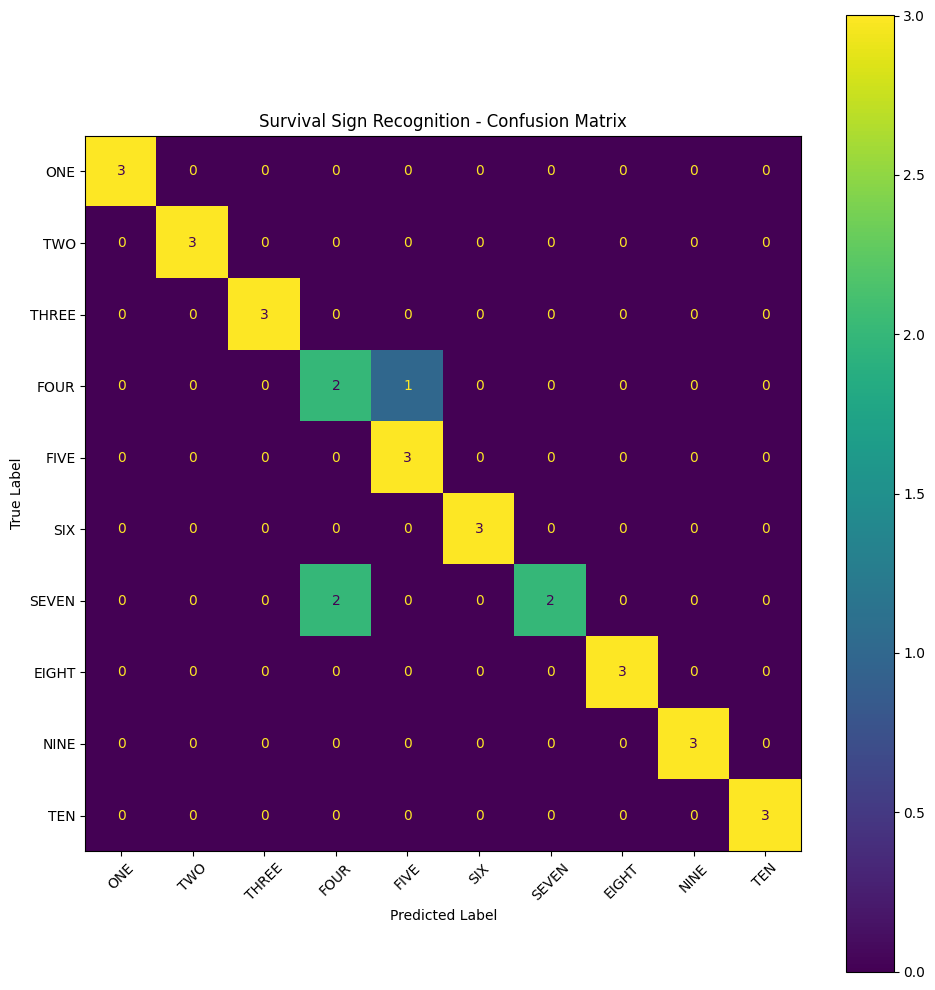

ONE                 : 100.00%
TWO                 : 100.00%
THREE               : 100.00%
FOUR                : 66.67%
FIVE                : 100.00%
SIX                 : 100.00%
SEVEN               : 50.00%
EIGHT               : 100.00%
NINE                : 100.00%
TEN                 : 100.00%


In [3]:
import sys
import importlib
from pathlib import Path
import torch

REPO_ROOT = Path(r"C:\Projects\signia-fsl-recognition").resolve()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.evaluation.metrics
importlib.reload(src.evaluation.metrics)

from src.evaluation.metrics import plot_confusion_matrix

test_loader = result["test_loader"]
model = result["model"]
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

class_names = [
"ONE",
"TWO",
"THREE",
"FOUR",
"FIVE",
"SIX",
"SEVEN",
"EIGHT",
"NINE",
"TEN"
]

cm = plot_confusion_matrix(
    model= model,
    test_loader=test_loader,
    class_names=class_names,
    device=device,
    save_path=(
        REPO_ROOT
        / "artifacts"
        / "models"
        / "survival"
        / "confusion_matrix.png"
    ),
)



import numpy as np

class_accuracy = np.diag(cm) / cm.sum(axis=1)

for label, accuracy in zip(class_names, class_accuracy):
    print(f"{label:20s}: {accuracy:.2%}")

In [1]:
import sys
from importlib import reload
from pathlib import Path

REPO_ROOT = Path(r"C:\Projects\signia-fsl-recognition").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.training.trainer as trainer_module

trainer_module = reload(trainer_module)
TrainingConfig = trainer_module.TrainingConfig
train = trainer_module.train


config = TrainingConfig(
    dataset_path=str(
        REPO_ROOT / "notebooks" / "02_dynamic" / "fsl_dataset_clean.pt"
    ),
    label_ids=[30, 31, 32, 33, 34, 35, 36, 37, 38, 39,40,41],
    labels_csv=str(REPO_ROOT / "csv" / "labels.csv"),
    model_type="sign_lstm",
    output_dir=str(REPO_ROOT / "artifacts" / "models" / "calendar"),
    model_name="greetings_lstm",
    batch_size=8,
    epochs=50,
    learning_rate=0.001,
    patience=10,
    random_state=42,
)

result = train(config)

result



Device: cpu
Selected labels: [30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]
Loaded dataset bundle: C:\Projects\signia-fsl-recognition\notebooks\02_dynamic\fsl_dataset_clean.pt
Dataset samples: 247
Classes: [30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]
Number of classes: 12
Dataset shape: (247, 30, 126)
Labels shape: (247,)
Detected input size: 126
Encoded labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

Classes to be trained:
 id     label category
 30   JANUARY CALENDAR
 31  FEBRUARY CALENDAR
 32     MARCH CALENDAR
 33     APRIL CALENDAR
 34       MAY CALENDAR
 35      JUNE CALENDAR
 36      JULY CALENDAR
 37    AUGUST CALENDAR
 38 SEPTEMBER CALENDAR
 39   OCTOBER CALENDAR
 40  NOVEMBER CALENDAR
 41  DECEMBER CALENDAR
Train: 172
Validation: 37
Test: 38

Model:
SignLSTM(
  (lstm): LSTM(126, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=12, bias=True)
)
Model classes: 12
Encoded labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Epoch 01/

{'model': SignLSTM(
   (lstm): LSTM(126, 128, num_layers=2, batch_first=True, dropout=0.3)
   (fc): Linear(in_features=128, out_features=12, bias=True)
 ),
 'label_encoder': <src.training.label_encoder.ModelLabelEncoder at 0x28a8e8b5100>,
 'history': {'train_loss': [2.484979740408964,
   2.1916025544321815,
   1.8376334711562756,
   1.9916506312614264,
   1.60056734085083,
   1.4491513385329136,
   1.4724178730055344,
   1.2967126702153406,
   1.2430482853290648,
   1.1465485622716505,
   0.9740539428799652,
   0.9639786592749662,
   0.9204911880714949,
   0.7325963863106661,
   0.7386456908181657,
   0.7697486322979594,
   0.7293795970983283,
   1.0383960590806118,
   1.0551434935525406,
   0.7704242925311244,
   0.6769971819811089,
   0.5778426139853722,
   0.5307145347428877,
   0.5504033808098283,
   0.5982502099386481,
   0.5557492877854857,
   0.5850902144298997,
   0.46593649373498075,
   0.5081232467363047,
   0.583724630606729,
   0.6536076623339986,
   0.6320514124493266],
  

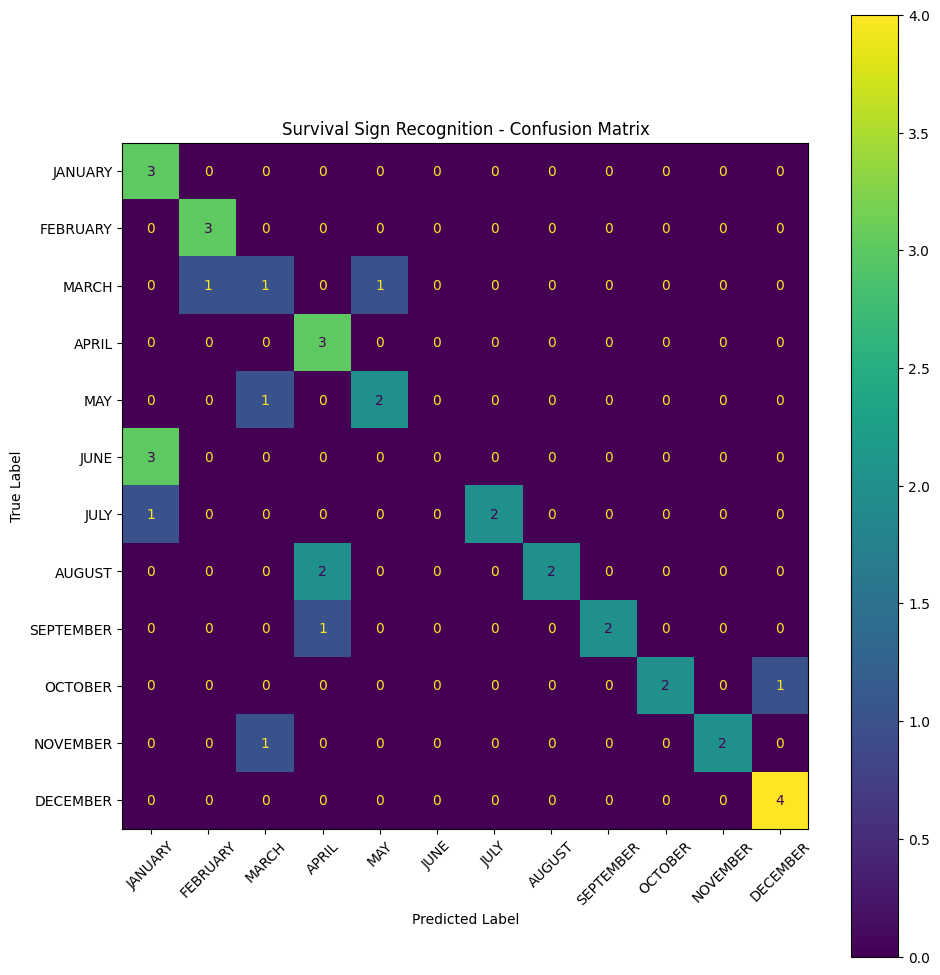

JANUARY             : 100.00%
FEBRUARY            : 100.00%
MARCH               : 33.33%
APRIL               : 100.00%
MAY                 : 66.67%
JUNE                : 0.00%
JULY                : 66.67%
AUGUST              : 50.00%
SEPTEMBER           : 66.67%
OCTOBER             : 66.67%
NOVEMBER            : 66.67%
DECEMBER            : 100.00%


In [2]:
import sys
import importlib
from pathlib import Path
import torch

REPO_ROOT = Path(r"C:\Projects\signia-fsl-recognition").resolve()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.evaluation.metrics
importlib.reload(src.evaluation.metrics)

from src.evaluation.metrics import plot_confusion_matrix

test_loader = result["test_loader"]
model = result["model"]
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

class_names = [
"JANUARY",
"FEBRUARY",
"MARCH",
"APRIL",
"MAY",
"JUNE",
"JULY",
"AUGUST",
"SEPTEMBER",
"OCTOBER",
"NOVEMBER",
"DECEMBER",
]

cm = plot_confusion_matrix(
    model= model,
    test_loader=test_loader,
    class_names=class_names,
    device=device,
    save_path=(
        REPO_ROOT
        / "artifacts"
        / "models"
        / "survival"
        / "confusion_matrix.png"
    ),
)



import numpy as np

class_accuracy = np.diag(cm) / cm.sum(axis=1)

for label, accuracy in zip(class_names, class_accuracy):
    print(f"{label:20s}: {accuracy:.2%}")

Days

In [ ]:
import sys
from importlib import reload
from pathlib import Path

REPO_ROOT = Path(r"C:\Projects\signia-fsl-recognition").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.training.trainer as trainer_module

trainer_module = reload(trainer_module)
TrainingConfig = trainer_module.TrainingConfig
train = trainer_module.train


config = TrainingConfig(
    dataset_path=str(
        REPO_ROOT / "notebooks" / "02_dynamic" / "fsl_dataset_clean.pt"
    ),
    label_ids=[42,43,44,45,46,47,48,49,50,51],
    labels_csv=str(REPO_ROOT / "csv" / "labels.csv"),
    model_type="sign_lstm",
    output_dir=str(REPO_ROOT / "artifacts" / "models" / "calendar"),
    model_name="greetings_lstm",
    batch_size=8,
    epochs=50,
    learning_rate=0.001,
    patience=10,
    random_state=42,
)

result = train(config)

result



Family

In [ ]:
import sys
from importlib import reload
from pathlib import Path

REPO_ROOT = Path(r"C:\Projects\signia-fsl-recognition").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.training.trainer as trainer_module

trainer_module = reload(trainer_module)
TrainingConfig = trainer_module.TrainingConfig
train = trainer_module.train


config = TrainingConfig(
    dataset_path=str(
        REPO_ROOT / "notebooks" / "02_dynamic" / "fsl_dataset_clean.pt"
    ),
    label_ids=[52,53,54,55,56,57,58,59,60,61],
    labels_csv=str(REPO_ROOT / "csv" / "labels.csv"),
    model_type="sign_lstm",
    output_dir=str(REPO_ROOT / "artifacts" / "models" / "calendar"),
    model_name="greetings_lstm",
    batch_size=8,
    epochs=50,
    learning_rate=0.001,
    patience=10,
    random_state=42,
)

result = train(config)

result

